### Question score

For getting the percentage score for a question, we will use logistice function as follows: 

$$
p(min-answers, price) = \frac{0.99}{1+e^{-(\beta_0 + \beta_1 \cdot X_{price} + \beta_2 \cdot X_{min-answers})}},\ \beta_0, \beta_1 > 0,\ \beta_2 < 0
$$

where $X_{price}$ is the price normalized by the effort score we will define next,  and $X_{min-answers}$ is an increasing function of the minimum number of answers, i.e
$$
X_{price} = \frac{price}{\mathcal{E}}, \quad X_{min-answers} = \log(1+min-answers)
$$

We define the effort $\mathcal{E}$ depending on the type score $type$ and the the length $l$ of the question. 
$$
\mathcal{E} = \alpha \cdot \log(l) + \beta \cdot type + \gamma \cdot (c-1)^p H(c-3),\ p>0
$$

where $c$ is the number of categories and $H$ is the Heaviside function.



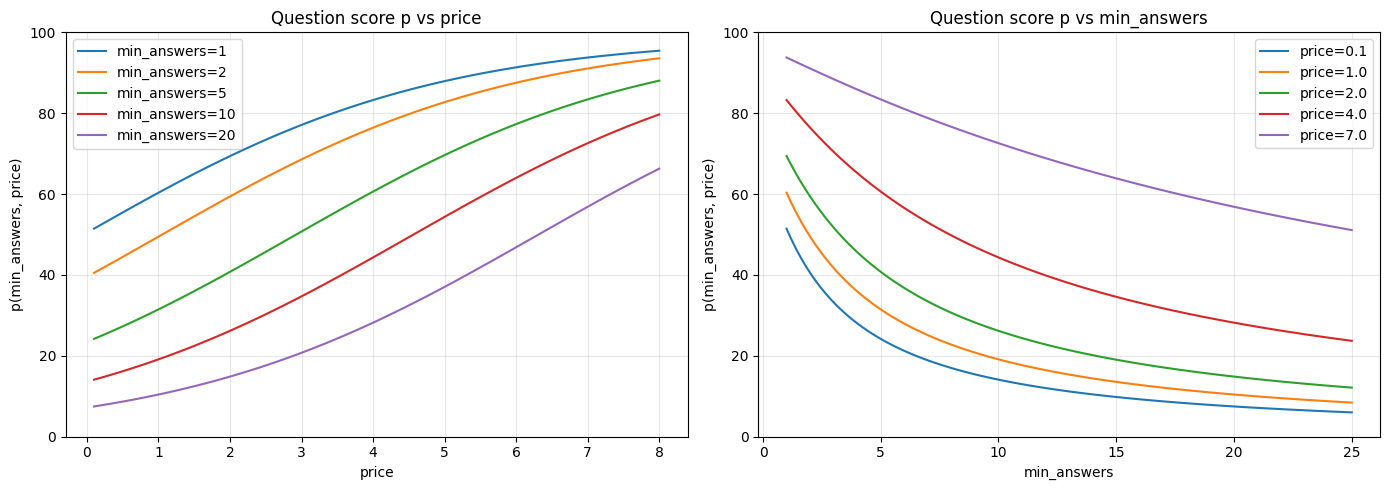

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt


def effort(length: float, type_score: float, alpha: float, beta_effort: float, gamma: float, c: int = 2, p: float = 1.5) -> float:
    return alpha * math.log(length,2) + beta_effort * type_score + gamma * (c)**p * np.heaviside(c-3, 0)


def question_score_p(
    min_answers: float,
    price: float,
    length: float,
    type_score: float,
    beta0: float,
    beta1: float,
    beta2: float,
    alpha: float,
    beta_effort: float,
    gamma: float,
    categories: int = 0,
    p: float = 1
) -> float:
    if min_answers < 0:
        raise ValueError("min_answers must be >= 0 because log(1 + min_answers) is used.")

    # EFFORT VALUE
    # If you wnat to make the question categorical, just change the number of categories to a value >= 2
    e = effort(length=length, type_score=type_score, alpha=alpha, beta_effort=beta_effort, gamma=gamma, c=categories, p=p)

    x_price = price / e
    x_min_answers = math.log1p(min_answers)
    z = beta0 + beta1 * x_price + beta2 * x_min_answers
    return 100 * 0.99 / (1.0 + math.exp(-z))


# MODEL COEFFICIENTS
params = dict(
    # LOGIT COEFFICIENTS
    beta0=0.8,
    beta1=1.3,
    beta2=-1.1,
    # EFFORT COEFFICIENTS
    alpha=0.42,
    beta_effort=0.9,
    gamma=1.2,
    # QUESTION VARIABLES
    length=10,
    type_score=2.0,
    categories=0,
    p=1
)

def plot_p(**kwargs):
    # --- Plot 1: p vs price for different min_answers ---
    prices = np.linspace(0.1, 8.0, 120)
    min_answers_list = [1, 2, 5, 10, 20]

    # --- Plot 2: p vs min_answers for different prices ---
    min_answers_grid = np.linspace(1, 25, 120)
    price_list = [0.1, 1.0, 2.0, 4.0, 7.0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for min_a in min_answers_list:
        y = [question_score_p(min_answers=min_a, price=pr, **kwargs) for pr in prices]
        axes[0].plot(prices, y, label=f"min_answers={min_a}")

    axes[0].set_title("Question score p vs price")
    axes[0].set_xlabel("price")
    axes[0].set_ylabel("p(min_answers, price)")
    axes[0].set_ylim(0, 100)
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    for pr in price_list:
        y = [question_score_p(min_answers=ma, price=pr, **kwargs) for ma in min_answers_grid]
        axes[1].plot(min_answers_grid, y, label=f"price={pr}")

    axes[1].set_title("Question score p vs min_answers")
    axes[1].set_xlabel("min_answers")
    axes[1].set_ylabel("p(min_answers, price)")
    axes[1].set_ylim(0, 100)
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_p(**params)


Note what happens for a question with triple lenght

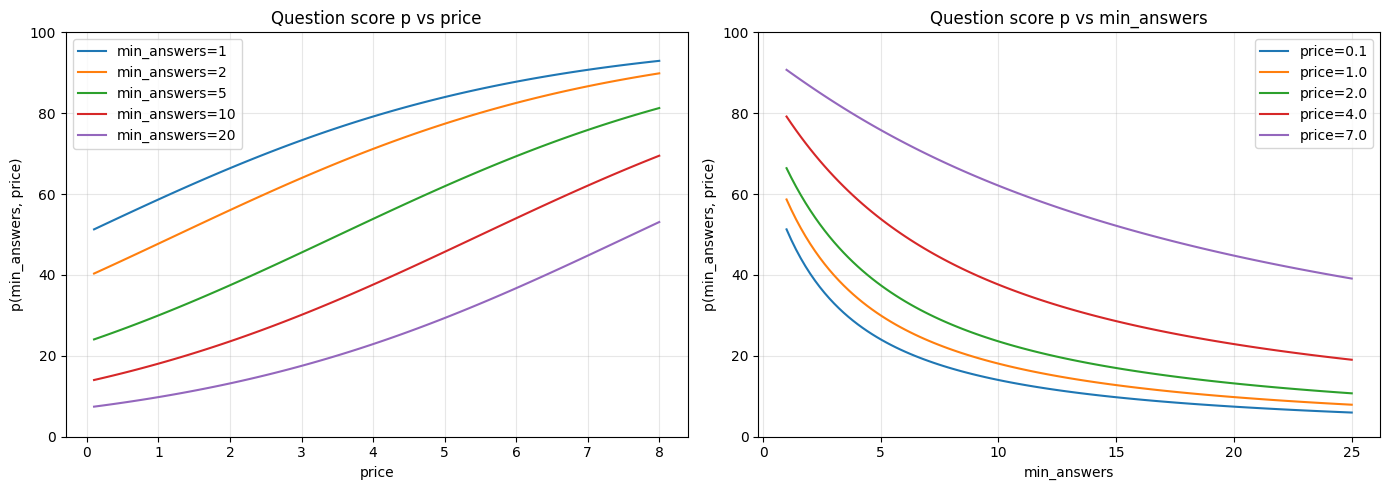

In [2]:
params['length'] = 30
plot_p(**params)

Now an abusive number of categories

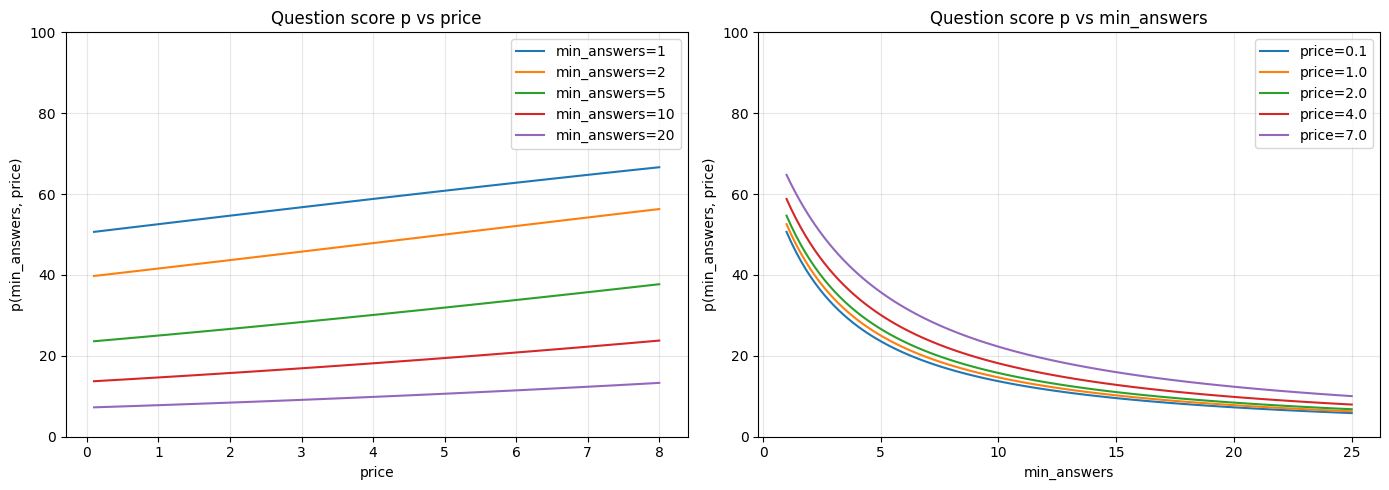

In [3]:
params['length'] = 10
params['categories'] = 10
plot_p(**params)